In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
master = pd.read_csv(
    "../data/cleaned/master_dataset.csv"
)

In [3]:
master["order_purchase_timestamp"] = pd.to_datetime(
    master["order_purchase_timestamp"]
)

In [4]:
monthly_revenue = (
    master
    .groupby(
        master["order_purchase_timestamp"]
        .dt.to_period("M")
    )["revenue"]
    .sum()
    .reset_index()
)

In [5]:
monthly_revenue["order_purchase_timestamp"] = (
    monthly_revenue["order_purchase_timestamp"]
    .dt.to_timestamp()
)

In [6]:
monthly_revenue.columns = [
    "Month",
    "Revenue"
]

In [7]:
monthly_revenue.head()

,Month,Revenue
0,2016-09-01,354.75
1,2016-10-01,58730.85
2,2016-12-01,19.62
3,2017-01-01,148030.11
4,2017-02-01,303648.31


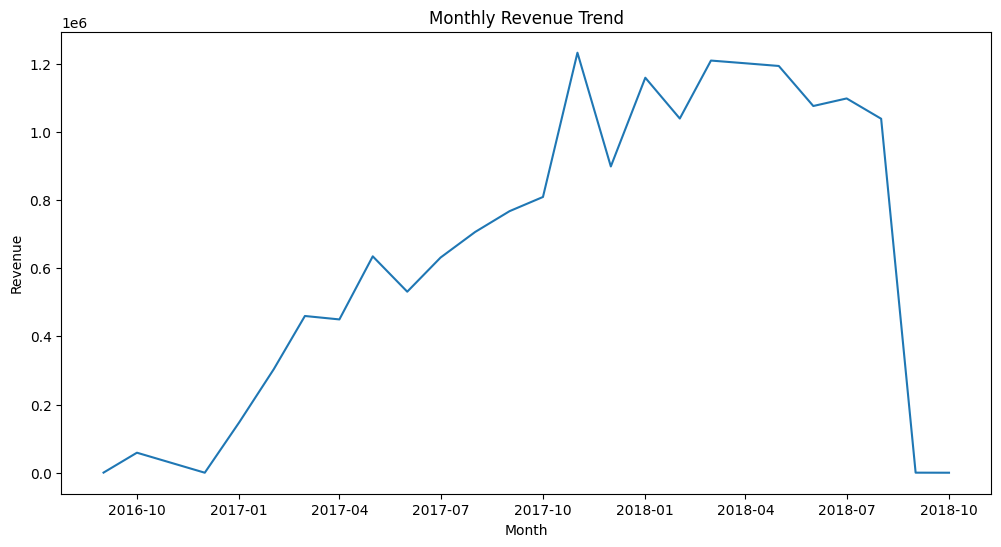

In [8]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"]
)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [9]:
monthly_revenue["MA_3"] = (
    monthly_revenue["Revenue"]
    .rolling(window=3)
    .mean()
)

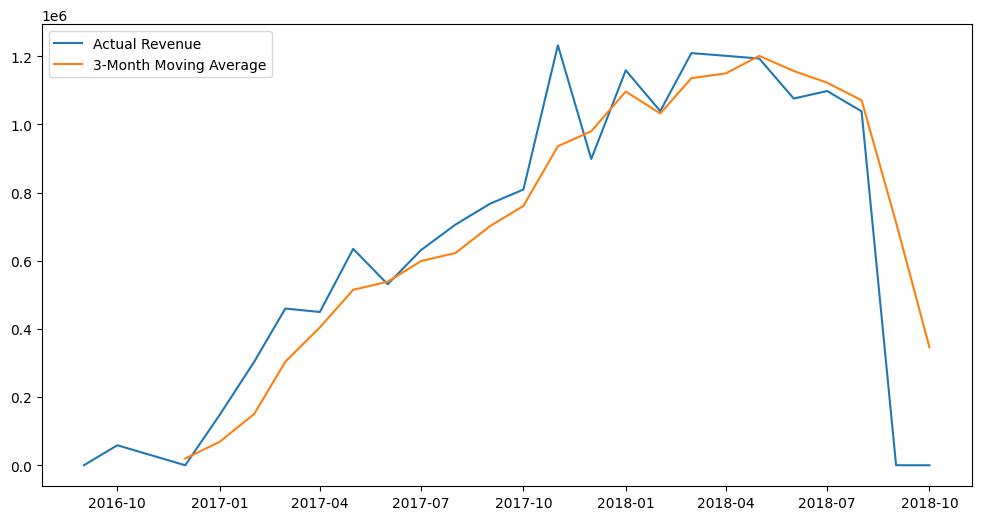

In [10]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    label="Actual Revenue"
)

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["MA_3"],
    label="3-Month Moving Average"
)

plt.legend()

plt.show()

In [11]:
monthly_revenue.tail()

,Month,Revenue,MA_3
20,2018-06-01,1075753.44,1.156687e+06
21,2018-07-01,1097939.54,1.122299e+06
22,2018-08-01,1038395.74,1.070696e+06
23,2018-09-01,166.46,7.121672e+05
24,2018-10-01,0.00,3.461874e+05


In [12]:
monthly_revenue = monthly_revenue.iloc[:-2]

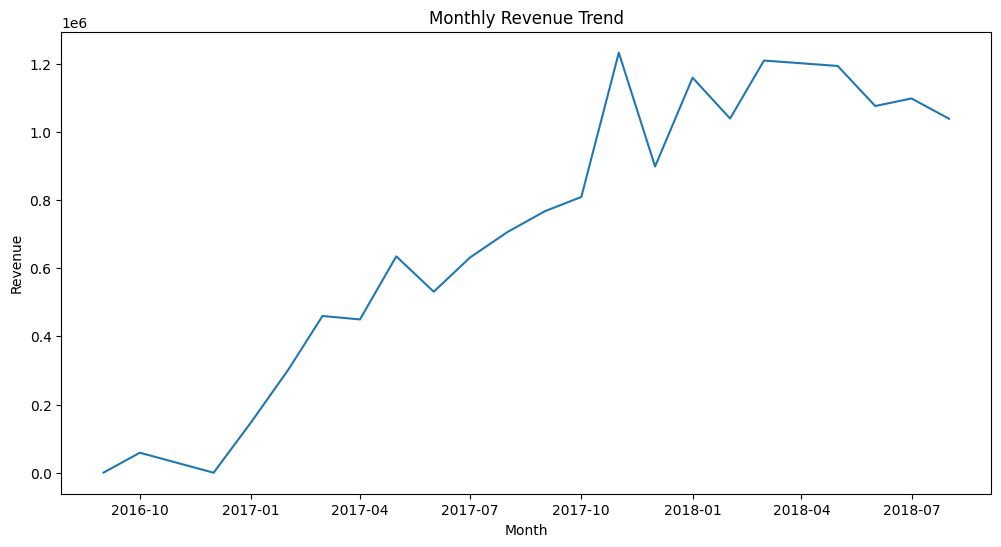

In [13]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"]
)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

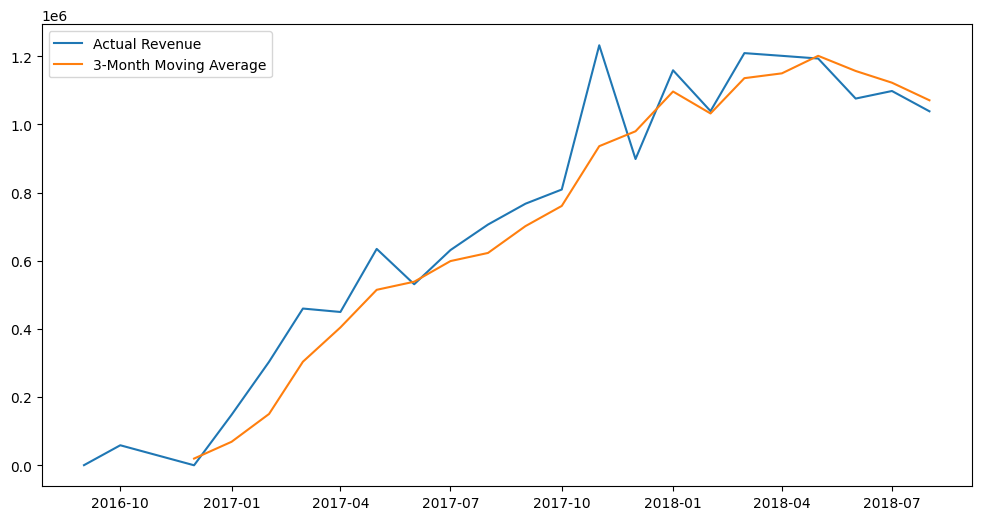

In [14]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    label="Actual Revenue"
)

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["MA_3"],
    label="3-Month Moving Average"
)

plt.legend()

plt.show()

In [15]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [16]:
model = ExponentialSmoothing(
    monthly_revenue["Revenue"],
    trend="add"
)

fit_model = model.fit()

In [17]:
forecast = fit_model.forecast(3)

forecast

23    1.075942e+06
24    1.045676e+06
25    1.015410e+06
dtype: float64

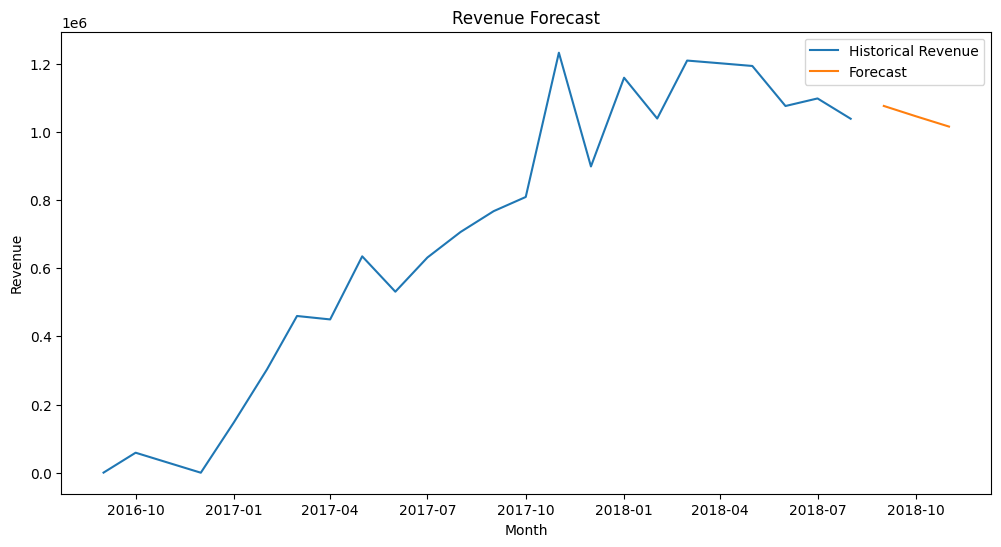

In [18]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    label="Historical Revenue"
)

future_months = pd.date_range(
    start=monthly_revenue["Month"].max(),
    periods=4,
    freq="MS"
)[1:]

plt.plot(
    future_months,
    forecast,
    label="Forecast"
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Revenue Forecast")
plt.legend()

plt.show()

In [19]:
forecast

23    1.075942e+06
24    1.045676e+06
25    1.015410e+06
dtype: float64

In [20]:
prophet_df = monthly_revenue[
    ["Month", "Revenue"]
].copy()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2016-09-01,354.75
1,2016-10-01,58730.85
2,2016-12-01,19.62
3,2017-01-01,148030.11
4,2017-02-01,303648.31


In [21]:
prophet_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      23 non-null     datetime64[us]
 1   y       23 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 500.0 bytes


In [22]:
from prophet import Prophet

model = Prophet()

model.fit(prophet_df)

Importing plotly failed. Interactive plots will not work.
23:09:42 - cmdstanpy - INFO - Chain [1] start processing
23:09:43 - cmdstanpy - INFO - Chain [1] done processing


In [23]:
future = model.make_future_dataframe(
    periods=6,
    freq="MS"
)

future.tail()

,ds
24,2018-10-01
25,2018-11-01
26,2018-12-01
27,2019-01-01
28,2019-02-01


In [24]:
forecast_prophet = model.predict(future)

In [25]:
forecast_prophet[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].tail(10)

,ds,yhat,yhat_lower,yhat_upper
19,2018-05-01,1.177881e+06,9.841917e+05,1.370394e+06
20,2018-06-01,1.235321e+06,1.039317e+06,1.417037e+06
21,2018-07-01,1.290909e+06,1.107102e+06,1.474188e+06
22,2018-08-01,1.348349e+06,1.168531e+06,1.539962e+06
23,2018-09-01,1.405790e+06,1.219985e+06,1.571611e+06
24,2018-10-01,1.461377e+06,1.280412e+06,1.641371e+06
25,2018-11-01,1.518818e+06,1.333987e+06,1.705794e+06
26,2018-12-01,1.574405e+06,1.391039e+06,1.759155e+06
27,2019-01-01,1.631846e+06,1.450619e+06,1.818831e+06
28,2019-02-01,1.689286e+06,1.502457e+06,1.871915e+06


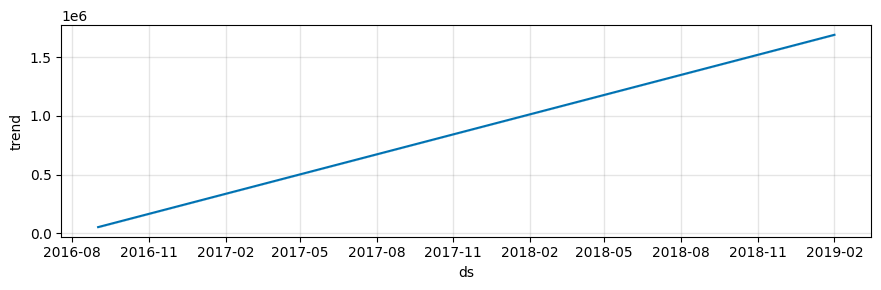

In [26]:
fig2 = model.plot_components(forecast_prophet)

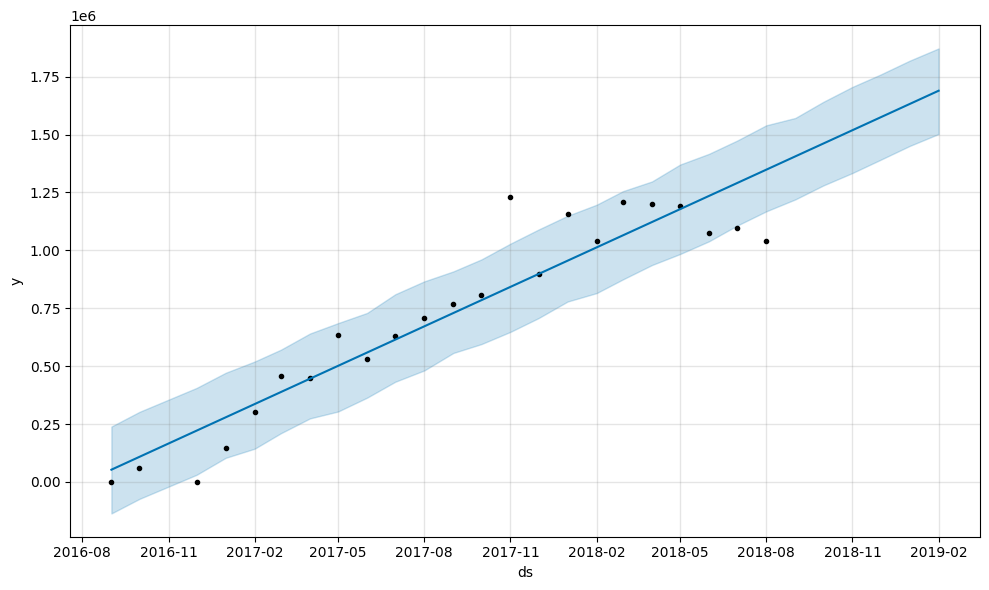

In [27]:
fig = model.plot(forecast_prophet)


In [28]:
monthly_revenue = (
    master
    .groupby(
        master["order_purchase_timestamp"].dt.to_period("M")
    )["revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["Month"] = (
    monthly_revenue["order_purchase_timestamp"]
    .astype(str)
)

monthly_revenue.drop(
    columns="order_purchase_timestamp",
    inplace=True
)

monthly_revenue.head()

,revenue,Month
0,354.75,2016-09
1,58730.85,2016-10
2,19.62,2016-12
3,148030.11,2017-01
4,303648.31,2017-02


In [36]:
prophet_df = monthly_revenue.copy()

prophet_df.columns = ["ds", "y"]

prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])

prophet_df.head()

,ds,y
0,1970-01-01 00:00:00.000000354,2016-09
1,1970-01-01 00:00:00.000058730,2016-10
2,1970-01-01 00:00:00.000000019,2016-12
3,1970-01-01 00:00:00.000148030,2017-01
4,1970-01-01 00:00:00.000303648,2017-02


In [37]:
prophet_df = monthly_revenue.rename(
    columns={
        "Month": "ds",
        "revenue": "y"
    }
)

prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])

prophet_df.head()

,y,ds
0,354.75,2016-09-01
1,58730.85,2016-10-01
2,19.62,2016-12-01
3,148030.11,2017-01-01
4,303648.31,2017-02-01


In [38]:
prophet_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   y       25 non-null     float64       
 1   ds      25 non-null     datetime64[us]
dtypes: datetime64[us](1), float64(1)
memory usage: 532.0 bytes


In [39]:
from prophet import Prophet

model = Prophet()

model.fit(prophet_df)

23:17:34 - cmdstanpy - INFO - Chain [1] start processing
23:17:35 - cmdstanpy - INFO - Chain [1] done processing


In [40]:
future = model.make_future_dataframe(
    periods=6,
    freq="ME"
)

forecast = model.predict(future)

In [41]:
forecast[["ds","yhat"]].tail(10)

,ds,yhat
21,2018-07-01,1.247151e+06
22,2018-08-01,1.215432e+06
23,2018-09-01,3.506621e+05
24,2018-10-01,3.293498e+05
25,2018-10-31,4.559566e+06
26,2018-11-30,2.302982e+06
27,2018-12-31,2.223746e+06
28,2019-01-31,1.917174e+05
29,2019-02-28,7.403192e+05
30,2019-03-31,1.692989e+06


In [42]:
forecast_data = forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
]

forecast_data.tail(10)

,ds,yhat,yhat_lower,yhat_upper
21,2018-07-01,1.247151e+06,9.834119e+05,1.512976e+06
22,2018-08-01,1.215432e+06,9.574591e+05,1.508202e+06
23,2018-09-01,3.506621e+05,8.423546e+04,6.324643e+05
24,2018-10-01,3.293498e+05,6.788382e+04,6.124696e+05
25,2018-10-31,4.559566e+06,4.264863e+06,4.842135e+06
26,2018-11-30,2.302982e+06,2.021633e+06,2.575364e+06
27,2018-12-31,2.223746e+06,1.957184e+06,2.507343e+06
28,2019-01-31,1.917174e+05,-9.365193e+04,4.585114e+05
29,2019-02-28,7.403192e+05,4.852936e+05,1.034786e+06
30,2019-03-31,1.692989e+06,1.436232e+06,1.979986e+06


In [43]:
forecast_data.to_csv(
    "../data/cleaned/forecast_data.csv",
    index=False
)

In [45]:
monthly_revenue.to_csv(
    "../data/cleaned/monthly_revenue.csv",
    index=False
)

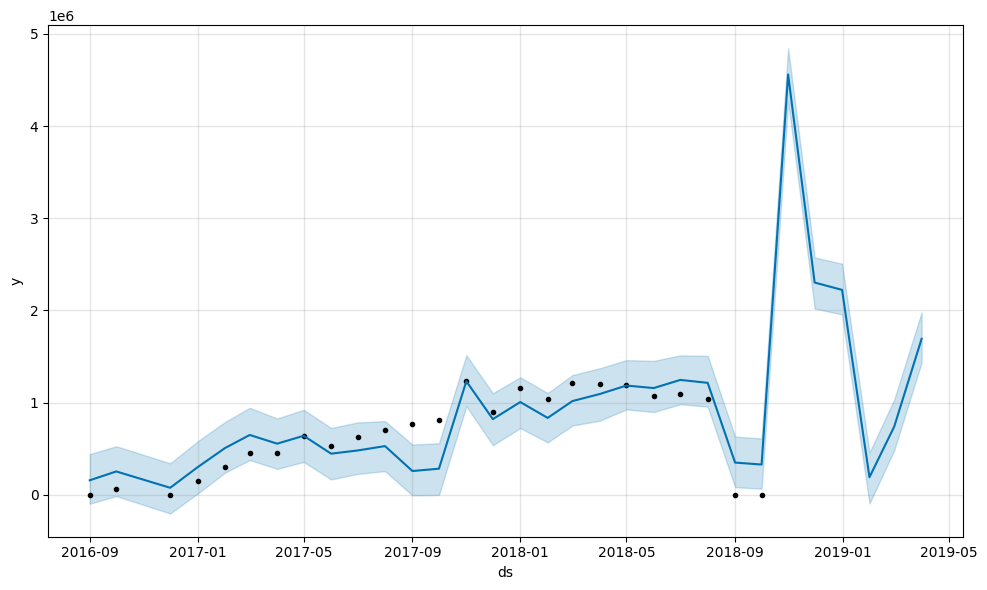

In [46]:
fig1 = model.plot(forecast)

fig1.savefig(
    "../images/10_prophet_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

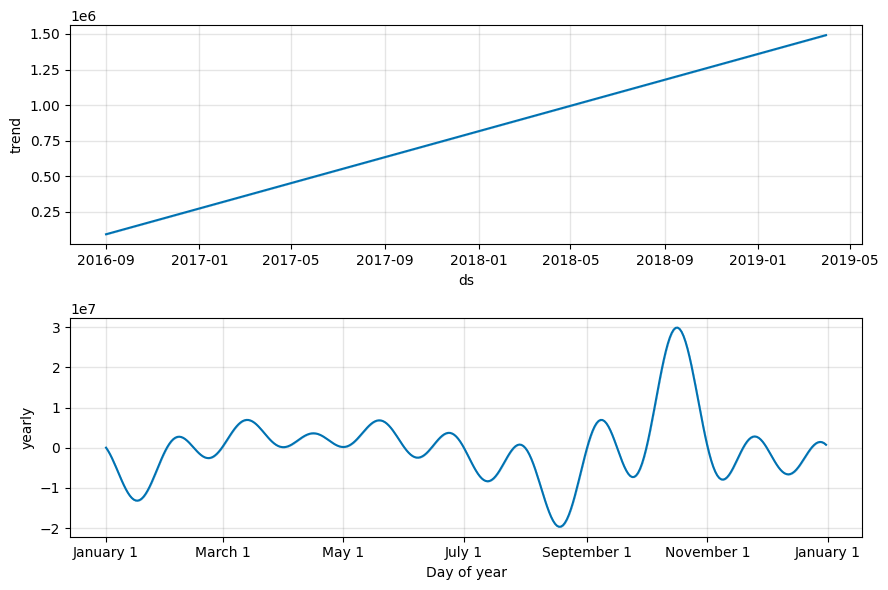

In [47]:
fig2 = model.plot_components(forecast)

fig2.savefig(
    "../images/11_prophet_components.png",
    dpi=300,
    bbox_inches="tight"
)